In [1]:
dataset = "https://raw.githubusercontent.com/ronaldleonardo/Data_Transformer_Datasets/refs/heads/main/bbc_text_cls.csv"

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import re
import string
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
nltk.download('averaged_perceptron_tagger_eng')

from tqdm import tqdm, tqdm_notebook
tqdm.pandas()

try:
  from wordcloud import WordCloud
except:
  !pip install wordcloud
  from wordcloud import WordCloud

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [6]:
data = pd.read_csv(dataset)

In [7]:
data.head()

,text,labels
0,Ad sales boost Time Warner profit\n\nQuarterly...,business
1,Dollar gains on Greenspan speech\n\nThe dollar...,business
2,Yukos unit buyer faces loan claim\n\nThe owner...,business
3,High fuel prices hit BA's profits\n\nBritish A...,business
4,Pernod takeover talk lifts Domecq\n\nShares in...,business


In [8]:
data["text"][0]

'Ad sales boost Time Warner profit\n\nQuarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.\n\nThe firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales. TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn. Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.\n\nTime Warner said on Friday that it now owns 8% of search-engine Google. But its own internet business, AOL, had has mixed fortunes. It lost 464,000 subscribers in the fourth quarter profits were lower than in the preceding three quarters. However, the company said AOL\'s underlying profit before exceptional items rose 8% on the back of stronger internet advertising revenues. It hopes to increase subscribers by offering the online service free to TimeWarner internet customers and will try to sig

In [9]:
data.shape

(2224, 2)

In [10]:
data.labels.value_counts()

labels
business         510
sport            510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

<Axes: xlabel='labels', ylabel='count'>

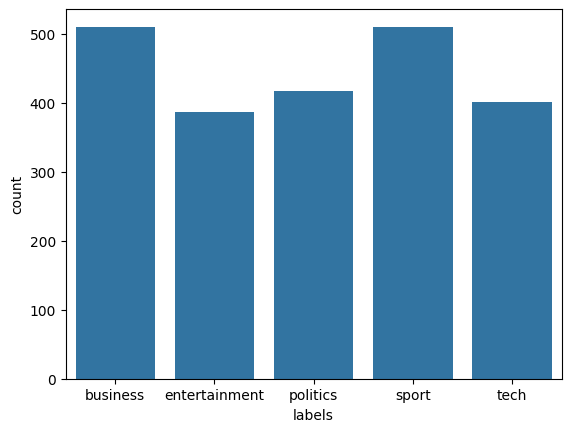

In [11]:

sns.countplot(data = data, x = 'labels')

In [12]:
X = data.text
y = data.labels
X.shape, y.shape

((2224,), (2224,))

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1668,), (556,), (1668,), (556,))

In [14]:
%time text = ' '.join(X_train.loc[y_train == 'sport'])
text

CPU times: total: 15.6 ms
Wall time: 14.3 ms


'Isinbayeva heads for Birmingham\n\nOlympic pole vault champion Yelena Isinbayeva has confirmed she will take part in the 2005 Norwich Union Grand Prix in Birmingham on 18 February.\n\n"Everybody knows how much I enjoy competing in Britain. I always seem to break records there," said Isinbayeva. "As Olympic champion there will be more attention on me this year, but hopefully I can respond with another record in Birmingham." Kelly Holmes and Carolina Kluft are among other Athens winners competing. The organisers are hoping that Isinbayeva\'s main rival, fellow Russian Svetlana Feofanova, will also take part in the event. The pair had a thrilling battle in Athens which ended with Isinbayeva finally jumping a world record of 4.91m to claim the gold medal. Isinbayeva, 22, has set 10 world records in the pole vault, three of which have come on British soil. Scrum-half Williams rejoins Bath\n\nBath have signed their former scrum-half Andy Williams on a short-term deal from the Neath-Swansea 

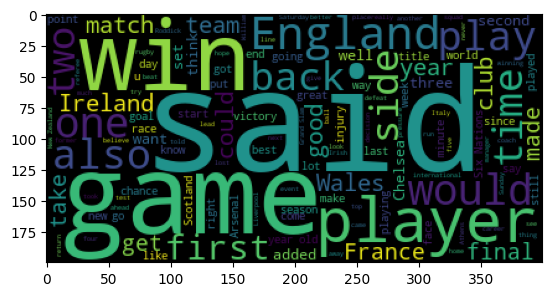

In [15]:
word_cloud = WordCloud(stopwords = stopwords.words('english')).generate(text)
plt.imshow(word_cloud)

## Text preprocessing

In [16]:
# Text cleaning
def clean(document, stem = False):
  # Remove Special Characters from string
  pattern = r'[^a-zA-Z.]'
  document = re.sub(pattern, ' ', document)

  # Convert document to lower case
  document = document.lower()

  # Tokenization
  vocab = word_tokenize(document)

  # Remove punctuation from string
  vocab = [word for word in vocab if word not in string.punctuation]

  # Remove stopwords
  stop = stopwords.words('english')
  vocab = [word for word in vocab if word not in stop]

  # Stemming or Lemmitazation
  if stem:
    stemmer = PorterStemmer()
    vocab = [stemmer.stem(word)for word in vocab]

  else:
    lemmatizer = WordNetLemmatizer()
    def wordnet_pos(word):
      tag = nltk.pos_tag([word])[0][1][0]
      tag_dict = {'N': wordnet.NOUN,
                  'V': wordnet.VERB,
                  'J':wordnet.ADJ,
                  'R': wordnet.ADV}
      return tag_dict.get(tag, wordnet.NOUN)
    vocab = [lemmatizer.lemmatize(word, wordnet_pos(word)) for word in vocab]
  return ' '.join(vocab)

In [17]:
def tokenize(doc):
  return word_tokenize(doc)

In [20]:
clean(text)

'isinbayeva head birmingham olympic pole vault champion yelena isinbayeva confirm take part norwich union grand prix birmingham february everybody know much enjoy compete britain always seem break record say isinbayeva olympic champion attention year hopefully respond another record birmingham kelly holmes carolina kluft among athens winner compete organiser hop isinbayeva main rival fellow russian svetlana feofanova also take part event pair thrill battle athens end isinbayeva finally jumping world record claim gold medal isinbayeva set world record pole vault three come british soil scrum half williams rejoins bath bath sign former scrum half andy williams short term deal neath swansea osprey wale international williams whose contract welsh region due expire june agree contract end season martyn wood injury likely keep february bath need experienced back nick walshe say williams opportunity present really think twice williams capped wale romania figure match squad monday zurich premi

In [26]:
data["text"].apply(clean, args=(True,))

0       ad sale boost time warner profit quarterli pro...
1       dollar gain greenspan speech dollar hit highes...
2       yuko unit buyer face loan claim owner embattl ...
3       high fuel price hit ba profit british airway b...
4       pernod takeov talk lift domecq share uk drink ...
                              ...                        
2219    bt program beat dialler scam bt introduc two i...
2220    spam e mail tempt net shopper comput user acro...
2221    care code new european direct could put softwa...
2222    us cyber secur chief resign man make sure us c...
2223    lose onlin game onlin role play game time cons...
Name: text, Length: 2224, dtype: object

In [28]:
from platform import processor
#vect = CountVectorizer(preprocessor = lambda x:clean(x,stem=True), tokenizer = tokenize)
vect = CountVectorizer(preprocessor = clean)
vect

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",<function cle...002A443A1B4C0>
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",'word'


In [31]:
X_train_transformed = vect.fit_transform(X_train)
X_train_transformed.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1668, 19502))

In [32]:
X_train_transformed.shape

(1668, 19502)

In [33]:
X_train_transformed.toarray().max()

np.int64(81)

In [34]:
nb = MultinomialNB()
nb.fit(X_train_transformed, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [35]:
nb.score(X_train_transformed, y_train)

0.9952038369304557

In [36]:
X_test_transformed = vect.transform(X_test)
X_test_transformed

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 74632 stored elements and shape (556, 19502)>

In [37]:
y_pred = nb.predict(X_test_transformed)

In [38]:
accuracy_score(y_test, y_pred)

0.9658273381294964

In [39]:
cm = confusion_matrix(y_test, y_pred, labels = nb.classes_)
cm

array([[134,   0,   6,   0,   3],
       [  1,  94,   2,   0,   1],
       [  2,   0,  86,   0,   2],
       [  1,   0,   0, 119,   0],
       [  0,   1,   0,   0, 104]])

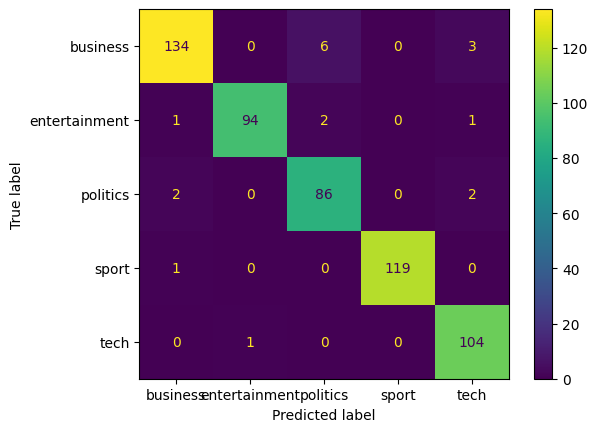

In [40]:
fig = ConfusionMatrixDisplay(cm, display_labels = nb.classes_)
fig.plot()